Integrador

$ q = \frac{m\cdot g}{l}$

$ q = \frac{m\cdot 2g}{l}$

### El primer predimensionado se hace con la masa total

In [ ]:
# Datos constantes

# modulo de elasticidad a traccion [N/m2]
mod_elt = 210e3*1e6

# modulo de elasticidad a compresi [N/m2]
mod_elc = 21e3*1e6

In [1]:
import pandas as pd

# DataFrame de designaciones (dimensiones únicas)
designaciones_df = pd.DataFrame([
    {"codigo": "A", "designacion": "38.1mm x 1.6mm", "area_cm2": 1.835, "inercia_cm4": 3.061},
    {"codigo": "B", "designacion": "38.1mm x 2mm",   "area_cm2": 2.268, "inercia_cm4": 3.706},
    {"codigo": "C", "designacion": "38.1mm x 2.5mm", "area_cm2": 2.796, "inercia_cm4": 4.451},
])

designaciones_df

,codigo,designacion,area_cm2,inercia_cm4
0,A,38.1mm x 1.6mm,1.835,3.061
1,B,38.1mm x 2mm,2.268,3.706
2,C,38.1mm x 2.5mm,2.796,4.451


In [2]:
[
    [0.000, 0.036],           # P1
    [0.350, 0.036],        # P2
    [0.724, 0.036],       # P3
    [1.291, 0.000],           # P4
    [2.010, 0.000],            # P5
    [2.315, 0.036],       # P6
    [0.000, 0.356],           # P7
    [0.350, 0.227],        # P8
    [0.697, 0.227],     # P9
    [1.325, 0.227],    # P10
    [2.010, 0.227],        # P11
    [2.315, 0.227],       # P12
    [0.350, 0.476],        # P13
    [0.650, 0.557],        # P14
    [0.993, 0.391],  # P15
    [1.395, 0.614],       # P16
    [1.395, 1.137],       # P17
]

[[0.0, 0.036],
 [0.35, 0.036],
 [0.724, 0.036],
 [1.291, 0.0],
 [2.01, 0.0],
 [2.315, 0.036],
 [0.0, 0.356],
 [0.35, 0.227],
 [0.697, 0.227],
 [1.325, 0.227],
 [2.01, 0.227],
 [2.315, 0.227],
 [0.35, 0.476],
 [0.65, 0.557],
 [0.993, 0.391],
 [1.395, 0.614],
 [1.395, 1.137]]

In [3]:
# Datos individuales por barra (número, código designación, masas)
barras_data = [
    (1,  "A", 0.77, 15.82),
    (2,  "A", 0.67, 13.71),
    (3,  "A", 0.82, 16.85),
    (4,  "A", 1.04, 21.32),
    (5,  "A", 0.44,  9.11),
    (6,  "B", 0.70,  3.63),
    (7,  "B", 0.88,  4.53),
    (8,  "B", 0.34,  1.76),
    (9,  "B", 0.71,  3.65),
    (10, "C", 0.28,  1.44),
    (11, "B", 0.92,  4.74),
    (12, "C", 0.33,  1.72),
    (13, "B", 1.09,  5.62),
    (14, "A", 0.33,  1.69),
    (15, "A", 0.28,  1.42),
    (16, "B", 0.54,  2.48),
    (17, "B", 0.50,  2.31),
    (18, "C", 0.91,  4.21),
    (19, "A", 0.98,  4.52),
    (20, "A", 0.44,  2.03),
    (21, "B", 0.53,  1.94),
    (22, "B", 0.36,  1.30),
    (23, "B", 0.62,  2.23),
    (24, "C", 0.48,  1.74),
    (25, "C", 0.49,  1.77),
    (26, "C", 0.54,  1.97),
    (27, "C", 0.57,  2.05),
    (28, "B", 1.05,  3.80),
    (29, "B", 0.45,  0.45),
    (30, "C", 0.55,  0.55),
    (31, "C", 0.66,  0.66),
    (32, "C", 0.75,  0.75),
    (33, "C", 1.58,  1.58),
]

# Crear el DataFrame
barras_df = pd.DataFrame(barras_data, columns=[
    "barra", "codigo", "masa_estructural_kg", "masa_total_kg"
])

# Hacer merge para obtener área e inercia según el código de designación
barras2 = barras_df.merge(designaciones_df, on="codigo")
barras2

,barra,codigo,masa_estructural_kg,masa_total_kg,designacion,area_cm2,inercia_cm4
0,1,A,0.77,15.82,38.1mm x 1.6mm,1.835,3.061
1,2,A,0.67,13.71,38.1mm x 1.6mm,1.835,3.061
2,3,A,0.82,16.85,38.1mm x 1.6mm,1.835,3.061
3,4,A,1.04,21.32,38.1mm x 1.6mm,1.835,3.061
4,5,A,0.44,9.11,38.1mm x 1.6mm,1.835,3.061
5,6,B,0.70,3.63,38.1mm x 2mm,2.268,3.706
6,7,B,0.88,4.53,38.1mm x 2mm,2.268,3.706
7,8,B,0.34,1.76,38.1mm x 2mm,2.268,3.706
8,9,B,0.71,3.65,38.1mm x 2mm,2.268,3.706
9,10,C,0.28,1.44,38.1mm x 2.5mm,2.796,4.451


In [4]:
import sys
sys.path.append('../trabajo_integrador/')
from barriga.modu import Rock
from barriga.ejemplos.ejemplo4 import datos as ejemplo

In [5]:

# Se cargan los datos
inc = ejemplo['inc']
iba = ejemplo['iba']
ino = ejemplo['ino']
car = ejemplo['car']
sop = ejemplo['sop']
con = ejemplo['con']
desig = ejemplo['desig']

# Se crea la estructura
mod = Rock(inc, iba, ino, car, sop,con, desig, pri=False)

In [6]:
lar:dict[int:int] = dict()
for bar in mod.lba:
    lar[bar.bar] = bar.lar

In [7]:
lar

{1: np.float64(0.35),
 2: np.float64(0.374),
 3: np.float64(0.5681417076751186),
 4: np.float64(0.7189999999999999),
 5: np.float64(0.3071172414567442),
 6: np.float64(0.32),
 7: np.float64(0.3987242154672826),
 8: np.float64(0.191),
 9: np.float64(0.39609342332333664),
 10: np.float64(0.19289893727027113),
 11: np.float64(0.635897004238894),
 12: np.float64(0.22953213282675697),
 13: np.float64(0.7539827584235596),
 14: np.float64(0.227),
 15: np.float64(0.191),
 16: np.float64(0.37301608544404624),
 17: np.float64(0.347),
 18: np.float64(0.628),
 19: np.float64(0.6849999999999998),
 20: np.float64(0.30500000000000016),
 21: np.float64(0.37),
 22: np.float64(0.24899999999999997),
 23: np.float64(0.4270948372434394),
 24: np.float64(0.3333301666516249),
 25: np.float64(0.33839621747294996),
 26: np.float64(0.3702971779530597),
 27: np.float64(0.3932797986167101),
 28: np.float64(0.7266319563575495),
 29: np.float64(0.3107426588030682),
 30: np.float64(0.38105773840718676),
 31: np.floa

In [10]:
# Convertir a DataFrame
largos = pd.DataFrame.from_dict(lar, orient='index', columns=['largo_m'])

# Opcional: resetear el índice si querés que sea una columna normal
largos = largos.reset_index().rename(columns={'index': 'barra'})

largos


,barra,largo_m
0,1,0.350000
1,2,0.374000
2,3,0.568142
3,4,0.719000
4,5,0.307117
5,6,0.320000
6,7,0.398724
7,8,0.191000
8,9,0.396093
9,10,0.192899


In [11]:
barras3 = barras2.merge(largos, on="barra")
barras3

,barra,codigo,masa_estructural_kg,masa_total_kg,designacion,area_cm2,inercia_cm4,largo_m
0,1,A,0.77,15.82,38.1mm x 1.6mm,1.835,3.061,0.350000
1,2,A,0.67,13.71,38.1mm x 1.6mm,1.835,3.061,0.374000
2,3,A,0.82,16.85,38.1mm x 1.6mm,1.835,3.061,0.568142
3,4,A,1.04,21.32,38.1mm x 1.6mm,1.835,3.061,0.719000
4,5,A,0.44,9.11,38.1mm x 1.6mm,1.835,3.061,0.307117
5,6,B,0.70,3.63,38.1mm x 2mm,2.268,3.706,0.320000
6,7,B,0.88,4.53,38.1mm x 2mm,2.268,3.706,0.398724
7,8,B,0.34,1.76,38.1mm x 2mm,2.268,3.706,0.191000
8,9,B,0.71,3.65,38.1mm x 2mm,2.268,3.706,0.396093
9,10,C,0.28,1.44,38.1mm x 2.5mm,2.796,4.451,0.192899


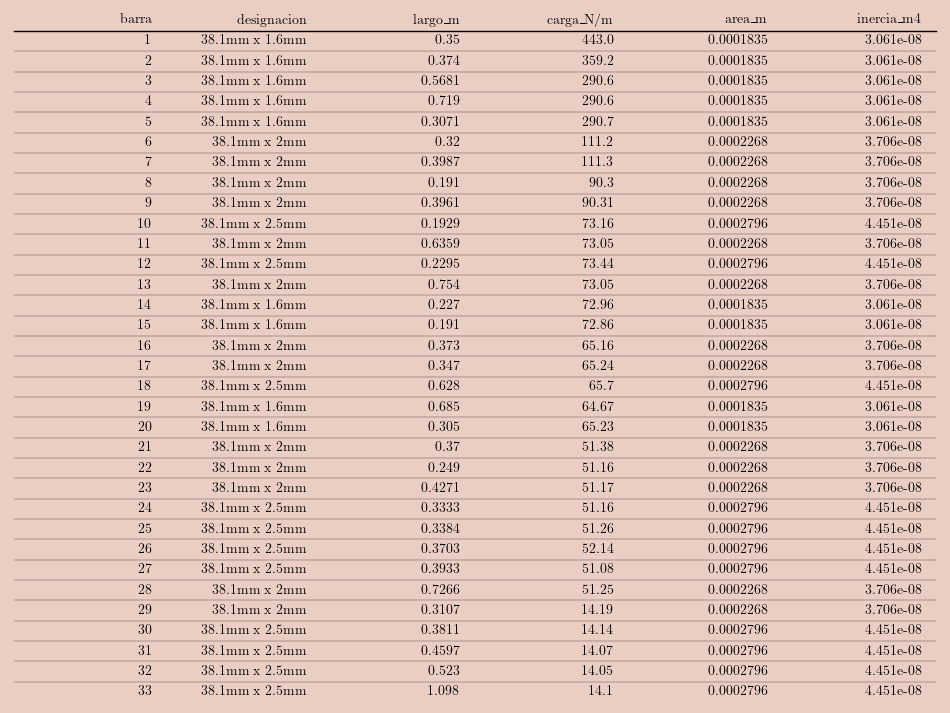

In [40]:
import numpy as np
from plottable import Table
import matplotlib.pyplot as plt
barras4 = barras3.copy()
barras4['carga_N/m'] = 9.8*barras4['masa_total_kg']/barras4['largo_m']
barras4['area_m'] = barras4['area_cm2']*10**(-4)
barras4['inercia_m4'] = barras4['inercia_cm4']*10**(-8)
barras4.drop('codigo', axis=1, inplace=True)
barras4.drop('area_cm2', axis=1, inplace=True)
barras4.drop('inercia_cm4', axis=1, inplace=True)
barras4.drop('masa_total_kg', axis=1, inplace=True)
barras4.drop('masa_estructural_kg', axis=1, inplace=True)
barras4 = barras4.set_index('barra')


fig, ax = plt.subplots(figsize=(12, 9))
# Parametros
plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']
plt.rcParams['text.latex.preamble'] = r'''
\usepackage{amsmath}
\usepackage{textgreek}
'''

# Configuraciones para figura
ax.set_facecolor('#EACEC4')
ax.set_axisbelow(True)
fig.patch.set_facecolor('#EACEC4')
ax.axis('off')

# Configuraciones para figura
dff = barras4.apply(
    lambda col: col.map(
        lambda x: f"{x:.4}" if isinstance(x, (np.number,float, )) else x)
)

tab = Table(dff, ax)

# Display the output
fig.savefig(f'sld_pre.png', bbox_inches='tight', dpi=250)